In [135]:
import os
import sys
import json

from pathlib import Path
from dotenv import load_dotenv


import matplotlib.pyplot as plt

path_proj = Path.cwd().parent
path_data = os.path.join(path_proj, "data")

load_dotenv()

sys.path.append(os.path.join(path_proj, "utils"))

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [136]:
neo4j_url = os.getenv("neo4jurl")
neo4j_user = os.getenv("noe4juser")
neo4j_password = os.getenv("neo4jpass")

In [137]:
from neo4j import GraphDatabase

with GraphDatabase.driver(neo4j_url, auth=(neo4j_user, neo4j_password)) as driver:
    driver.verify_connectivity()
    print("Successfully connected to Neo4j database")

Successfully connected to Neo4j database


In [138]:
driver = GraphDatabase.driver(neo4j_url, auth=(neo4j_user, neo4j_password))

with driver.session() as session:
    result = session.run("RETURN 1 AS number")
    record = result.single()
    print(f"Test query result: {record['number']}")

Test query result: 1


In [139]:
import pandas as pd
import ast

df_llm = pd.read_csv(os.path.join(path_data, "result_analysis.csv"))

df_llm["publication_date"] = pd.to_datetime(df_llm["publication_date"])
df_llm["embedding_signal"] = df_llm["embedding_signal"].apply(ast.literal_eval)

df_llm.head()

,url,title,publication_date,classification,score,signal,justification,evidence,embedding_signal
0,https://www.federalreserve.gov/newsevents/pres...,Federal Reserve issues FOMC statement,2026-01-28,mostly_dovish,-0.5,Low job gains and a stabilizing unemployment r...,The labor market is no longer described as str...,"Job gains have remained low, and the unemploym...","[-0.039459228515625, -0.01479339599609375, -0...."
1,https://www.federalreserve.gov/newsevents/pres...,Federal Reserve issues FOMC statement,2026-01-28,mostly_dovish,-0.5,Two FOMC members dissented in favor of an imme...,"The dissents provide a direct, though minority...","Stephen I. Miran and Christopher J. Waller, wh...","[0.010986328125, -0.03143310546875, -0.0175933..."
2,https://www.federalreserve.gov/newsevents/pres...,Federal Reserve issues FOMC statement,2026-01-28,neutral,0.0,The Committee retained a data-dependent approa...,The statement does not pre-commit to either cu...,the Committee will carefully assess incoming d...,"[-0.0172576904296875, -0.0224761962890625, -0...."
3,https://www.federalreserve.gov/newsevents/pres...,Federal Reserve issues FOMC statement,2026-01-28,neutral,0.0,The Committee emphasized two-sided risks aroun...,Attention to risks on both employment and infl...,The Committee is attentive to the risks to bot...,"[0.0009055137634277344, -0.0279388427734375, -..."
4,https://www.federalreserve.gov/newsevents/pres...,Federal Reserve issues FOMC statement,2026-01-28,neutral,0.0,The Committee stated it could adjust policy in...,This is a general contingency statement rather...,prepared to adjust the stance of monetary poli...,"[-0.006946563720703125, -0.0029315948486328125..."


In [140]:
df_llm.info()

<class 'pandas.DataFrame'>
RangeIndex: 10452 entries, 0 to 10451
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   url               10452 non-null  str           
 1   title             10452 non-null  str           
 2   publication_date  10452 non-null  datetime64[us]
 3   classification    10452 non-null  str           
 4   score             10452 non-null  float64       
 5   signal            10452 non-null  str           
 6   justification     10452 non-null  str           
 7   evidence          10452 non-null  str           
 8   embedding_signal  10452 non-null  object        
dtypes: datetime64[us](1), float64(1), object(1), str(6)
memory usage: 735.0+ KB


In [141]:
for ind, row in df_llm.iterrows():
    query = """
       MERGE (p:Publication {url: $url})
       SET
            p.title = $title,
            p.publication_date = $publication_date
    """

    records, summary, keys = driver.execute_query(
        query,
        parameters_={
            "url": row["url"],
            "title": row["title"],
            "publication_date": row["publication_date"].to_pydatetime(),
        }
    )

    # query = """
    #     MERGE (d:Date {date: $publication_date})
    #     """
    # records, summary, keys = driver.execute_query(
    #     query,
    #     parameters_={
    #         "publication_date": row["publication_date"].to_pydatetime(),
    #     }
    # )

    # query = """
    #     MATCH (p:Publication {url: $url})
    #     MATCH (d:Date {date: $publication_date})
    #     MERGE (p)-[:PUBLISHED_ON]->(d)
    # """
    # records, summary, keys = driver.execute_query(
    #     query,
    #     parameters_={
    #         "url": row["url"],
    #         "publication_date": row["publication_date"].to_pydatetime(),
    #     }
    # )

    query = """
        MERGE (s:Signal {text: $signal,
                         url: $url})
        SET s.classification = $classification,
            s.score = $score,
            s.justification = $justification,
            s.evidence = $evidence,
            s.embedding_signal = $embedding_signal,
            s.date = $publication_date
    """
    records, summary, keys = driver.execute_query(
        query,
        parameters_={
            "signal": row["signal"],
            "url": row["url"],
            "classification": row["classification"],
            "score": row["score"],
            "justification": row["justification"],
            "evidence": row["evidence"],
            "embedding_signal": row["embedding_signal"],
            "publication_date": row["publication_date"].to_pydatetime(),
        }
    )

    query = """
        MATCH (p:Publication {url: $url})
        MATCH (s:Signal {text: $signal,
                         url: $url})
        MERGE (p)-[:HAS_SIGNAL]->(s)
    """
    records, summary, keys = driver.execute_query(
        query,
        parameters_={
            "url": row["url"],
            "signal": row["signal"],
        }
    )
    print(f"Processed record {ind} with URL: {row['url']}")


Processed record 0 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 1 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 2 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 3 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 4 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 5 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 6 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 7 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 8 with URL: https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm
Processed record 9 with URL: https://

In [142]:
import json
from pathlib import Path

path_proj = Path.cwd().parent
path_data = path_proj / "data"

with open(path_data / "links_text.txt", "r", encoding="utf-8") as file:
    links_text = json.load(file)

links_text[0]

{'url': 'https://www.federalreserve.gov/newsevents/pressreleases/monetary20260128a.htm',
 'title': 'Federal Reserve issues FOMC statement',
 'text': "\ufeff\nFederal Reserve Board - Federal Reserve issues FOMC statement\nSkip to main content\nAn official website of the United States Government\nHere's how you know\nOfficial websites use .gov\nA\n.gov\nwebsite belongs to an official government organization in the United States.\nSecure .gov websites use HTTPS\nA\nlock\n(\nLock\nLocked padlock icon\n) or\nhttps://\nmeans you've safely connected to the .gov website. Share sensitive information only on official, secure websites.\nBack to Home\nBoard of Governors of the Federal Reserve System\nStay Connected\nFederal Reserve Facebook Page\nFederal Reserve Instagram Page\nFederal Reserve YouTube Page\nFederal Reserve Flickr Page\nFederal Reserve LinkedIn Page\nFederal Reserve Threads Page\nFederal Reserve X Page\nFederal Reserve Bluesky Page\nSubscribe to RSS\nSubscribe to Email\nRecent Post

In [143]:
len(links_text)

1310

In [144]:
target_title = "Federal Reserve issues FOMC statement"

dates_fomc_statement = sorted(
    {
        item.get("publication_date")
        for item in links_text
        if item.get("title") == target_title and item.get("publication_date")
    }
)

dates_fomc_statement

['2015-01-28',
 '2015-03-18',
 '2015-04-29',
 '2015-06-17',
 '2015-07-29',
 '2015-09-17',
 '2015-10-28',
 '2015-12-16',
 '2016-01-27',
 '2016-03-16',
 '2016-04-27',
 '2016-06-15',
 '2016-07-27',
 '2016-09-21',
 '2016-11-02',
 '2016-12-14',
 '2017-02-01',
 '2017-03-15',
 '2017-05-03',
 '2017-06-14',
 '2017-07-26',
 '2017-09-20',
 '2017-11-01',
 '2017-12-13',
 '2018-01-31',
 '2018-03-21',
 '2018-05-02',
 '2018-06-13',
 '2018-08-01',
 '2018-09-26',
 '2018-11-08',
 '2018-12-19',
 '2019-01-30',
 '2019-03-20',
 '2019-05-01',
 '2019-06-19',
 '2019-07-31',
 '2019-09-18',
 '2019-10-30',
 '2019-12-11',
 '2020-01-29',
 '2020-03-03',
 '2020-03-15',
 '2020-03-23',
 '2020-04-29',
 '2020-06-10',
 '2020-07-29',
 '2020-09-16',
 '2020-11-05',
 '2020-12-16',
 '2021-01-27',
 '2021-03-17',
 '2021-04-28',
 '2021-06-16',
 '2021-07-28',
 '2021-09-22',
 '2021-11-03',
 '2021-12-15',
 '2022-01-26',
 '2022-03-16',
 '2022-05-04',
 '2022-06-15',
 '2022-07-27',
 '2022-09-21',
 '2022-11-02',
 '2022-12-14',
 '2023-02-

In [145]:
from datetime import datetime

start_date = dates_fomc_statement[0]
end_date = dates_fomc_statement[1]

print(start_date)

2015-01-28


In [146]:
FRED_key = os.getenv('api_key_FRED')
api_key = FRED_key

print(api_key)

72f7955268d6a65a486d6ca126771837


In [147]:
import requests

def get_fred_data(id_data: str) -> pd.DataFrame:
    url = f'https://api.stlouisfed.org/fred/series/observations?series_id={id_data}&api_key={api_key}&file_type=json'
    response = requests.get(url)

    # Check to make sure the request was successful
    if response.status_code != 200:
        raise Exception('Failed to get data:', response.status_code)
    else:
        # Convert the response to a dictionary
        data = response.json()

        # Extract the 'observations' field from the data
        observations = data['observations']

        # Create a pandas DataFrame from the observations
        df = pd.DataFrame(observations)

        return df

# df_upper = get_fred_data('DFEDTARL')
# df_upper.head(5)

In [148]:
def get_diff_federal_funds() -> pd.DataFrame:
    df_lower = get_fred_data('DFEDTARL')[["date", "value"]].copy()
    df_upper = get_fred_data('DFEDTARU')[["date", "value"]].copy()

    df_lower["date"] = pd.to_datetime(df_lower["date"])
    df_lower["value"] = df_lower["value"].astype(float)
    df_upper["date"] = pd.to_datetime(df_upper["date"])
    df_upper["value"] = df_upper["value"].astype(float)
    df_lower = df_lower.rename(columns={"value": "lower_value"})
    df_upper = df_upper.rename(columns={"value": "upper_value"})

    return df_lower.merge(df_upper, on="date", how="inner")

In [149]:
df_fred = get_diff_federal_funds()

df_fred.head(5)

,date,lower_value,upper_value
0,2008-12-16,0.0,0.25
1,2008-12-17,0.0,0.25
2,2008-12-18,0.0,0.25
3,2008-12-19,0.0,0.25
4,2008-12-20,0.0,0.25


In [150]:
statement_dates = pd.to_datetime(dates_fomc_statement).normalize()
df_fred_statement_dates = df_fred[
    df_fred["date"].dt.normalize().isin(statement_dates)
].copy()
df_fred_statement_dates = df_fred_statement_dates.sort_values("date")
# df_fred_statement_dates["lower_rate_change"] = df_fred_statement_dates["lower_value"].diff()
df_fred_statement_dates["upper_rate_change"] = df_fred_statement_dates["upper_value"].diff().fillna(0)

df_fred_statement_dates.to_csv(
    path_data / "df_fred_statement_dates.csv",
    index=False,
)
df_fred_statement_dates

,date,lower_value,upper_value,upper_rate_change
2234,2015-01-28,0.0,0.25,0.0
2283,2015-03-18,0.0,0.25,0.0
2325,2015-04-29,0.0,0.25,0.0
2374,2015-06-17,0.0,0.25,0.0
2416,2015-07-29,0.0,0.25,0.0
...,...,...,...,...
6301,2026-03-18,3.5,3.75,0.0
6343,2026-04-29,3.5,3.75,0.0
6392,2026-06-17,3.5,3.75,0.0
6434,2026-07-29,3.5,3.75,0.0


# Rodando analises no grafo

In [151]:
from graph_utils import drop_projection

In [152]:
start_date = dates_fomc_statement[0]
end_date = dates_fomc_statement[1]

In [153]:
def drop_connections_similar():
    query = """
    MATCH ()-[r:SIMILAR_TO]-()
    DELETE r
    RETURN count(r) AS removed_relationships
    """
    records, summary, keys = driver.execute_query(query)
    print(f"{records[0]['removed_relationships']} SIMILAR_TO relationships removed")

In [154]:
def create_similar_connections(
        start_date,
        end_date,
        similarity_cutoff=0.8
        ):
    drop_connections_similar()
    drop_projection('signal-cypher')

    query = """
    MATCH (source:Signal)
    WHERE source.embedding_signal IS NOT NULL
        AND source.date >= localdatetime($start_date)
        AND source.date < localdatetime($end_date)
    WITH gds.graph.project(
        'signal-cypher',
        source,
        null,
        {
            sourceNodeProperties: source {.embedding_signal},
            targetNodeProperties: null
        }
    ) as g
    RETURN g.graphName AS graph, g.nodeCount AS nodes, g.relationshipCount AS rels
    """
    records, summary, keys = driver.execute_query(query,
                                                parameters_= {
                                                    "start_date": start_date,
                                                    "end_date": end_date,
                                                    }
    )


    print(f"Created graph 'signal-cypher' with {records[0]['nodes']}")


    query = """
    CALL gds.knn.stream(
        'signal-cypher',
        {
            nodeProperties: [
                {embedding_signal: 'COSINE'}
            ],
            similarityCutoff: $similarity_cutoff,
            topK: 50,
            randomSeed: 42,
            concurrency: 1
        }
    )
    YIELD node1, node2, similarity
    WITH
        gds.util.asNode(node1) AS n1,
        gds.util.asNode(node2) AS n2,
        similarity
    WHERE elementId(n1) < elementId(n2)
    MERGE (n1)-[r:SIMILAR_TO]-(n2)
    SET r.score_similarity = similarity
    RETURN count(r) AS total_score_relationships
    """
    records, summary, keys = driver.execute_query(
        query,
        parameters_={"similarity_cutoff": similarity_cutoff},
    )
    print(f"Criadas {records[0]['total_score_relationships']} relationships SIMILAR_TO")

create_similar_connections(start_date, end_date)

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


2342 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 63
Criadas 79 relationships SIMILAR_TO


In [155]:
def run_wcc(start_date, end_date):
    graph_name = "signal-wcc"
    drop_projection(graph_name)

    query = """
    MATCH (source:Signal)
    WHERE source.embedding_signal IS NOT NULL
        AND source.date >= localdatetime($start_date)
        AND source.date < localdatetime($end_date)

    OPTIONAL MATCH (source)-[r:SIMILAR_TO]-(target:Signal)
    WHERE target.embedding_signal IS NOT NULL
        AND target.date >= localdatetime($start_date)
        AND target.date < localdatetime($end_date)

    WITH gds.graph.project(
        'signal-wcc',
        source,
        target,
        {
            sourceNodeProperties: source {.embedding_signal, .score},
            targetNodeProperties: target {.embedding_signal, .score},
            relationshipProperties: r {.score_similarity}
        },
        {undirectedRelationshipTypes: ['*']}
    ) AS g
    RETURN g.graphName AS graph, g.nodeCount AS nodes, g.relationshipCount AS rels
    """
    records, summary, keys = driver.execute_query(
        query,
        parameters_={
            "start_date": start_date,
            "end_date": end_date,
        },
    )
    projection = records[0]
    print(
        f"Projection '{projection['graph']}': {projection['nodes']} nodes, "
        f"{projection['rels']} relationships"
    )

    query = """
    CALL gds.wcc.stream('signal-wcc')
    YIELD nodeId, componentId
    RETURN count(DISTINCT componentId) AS number_of_communities
    """
    records, summary, keys = driver.execute_query(query)
    number_of_communities = records[0]["number_of_communities"]
    print(f"{number_of_communities} communities")
    return number_of_communities

number_of_communities = run_wcc(start_date, end_date)

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Projection 'signal-wcc' removed
Projection 'signal-wcc': 63 nodes, 316 relationships
20 communities


In [156]:
def refine_similarity_cutoff(
    start_date,
    end_date,
    initial_cutoff=0.8,
    step=0.01,
    min_cutoff=0.1,
):
    similarity_cutoff = initial_cutoff

    while similarity_cutoff >= min_cutoff:
        create_similar_connections(start_date, end_date, similarity_cutoff)
        number_of_communities = run_wcc(start_date, end_date)

        if number_of_communities == 1:
            print(f"Single community reached with cutoff {similarity_cutoff:.2f}")
            return similarity_cutoff

        similarity_cutoff = round(similarity_cutoff - step, 10)

    raise RuntimeError(
        "A single community was not reached before the minimum cutoff."
    )

best_similarity_cutoff = refine_similarity_cutoff(start_date, end_date)

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


158 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed


Created graph 'signal-cypher' with 63


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Criadas 79 relationships SIMILAR_TO
Projection 'signal-wcc' removed


...

Criadas 494 relationships SIMILAR_TO
Projection 'signal-wcc' removed
Projection 'signal-wcc': 63 nodes, 1976 relationships
2 communities


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


988 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 63


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Criadas 605 relationships SIMILAR_TO
Projection 'signal-wcc' removed
Projection 'signal-wcc': 63 nodes, 2420 relationships
1 communities
Single community reached with cutoff 0.71


In [157]:
def run_leiden_communities(graph_name="signal-wcc"):
    query = """
    CALL gds.leiden.stream(
        $graph_name,
        {
            relationshipWeightProperty: 'score_similarity',
            randomSeed: 42,
            concurrency: 1
        }
    )
    YIELD nodeId, communityId
    RETURN
        nodeId,
        communityId,
        gds.util.asNode(nodeId).score AS node_score
    ORDER BY communityId
    """

    records, summary, keys = driver.execute_query(
        query,
        parameters_={"graph_name": graph_name},
    )
    return pd.DataFrame([record.data() for record in records])


leiden_results = run_leiden_communities()
number_of_leiden_communities = leiden_results["communityId"].nunique()
print(f"Número de comunidades Leiden: {number_of_leiden_communities}")
leiden_results.head()

Número de comunidades Leiden: 5


,nodeId,communityId,node_score
0,10801,1,-1.0
1,4434,1,-0.5
2,4442,1,0.5
3,4445,1,-1.0
4,4450,1,-0.5


In [158]:
def run_betweenness_centrality():
    query = """
    CALL gds.betweenness.stream(
        'signal-wcc',
        {relationshipWeightProperty: 'score_similarity'}
    )
    YIELD nodeId, score
    RETURN
        nodeId,
        score AS betweenness_centrality,
        gds.util.asNode(nodeId).score AS node_score
    ORDER BY betweenness_centrality DESC
    """
    records, summary, keys = driver.execute_query(query)
    return pd.DataFrame([record.data() for record in records])

betweenness_results = run_betweenness_centrality()
betweenness_results

,nodeId,betweenness_centrality,node_score
0,10788,212.0,0.5
1,10767,199.0,-1.0
2,10779,178.0,-1.0
3,4454,176.0,0.0
4,10798,120.0,0.0
...,...,...,...
58,10782,0.0,-0.5
59,10789,0.0,0.5
60,10793,0.0,-1.0
61,10797,0.0,-0.5


In [159]:
def run_weighted_degree_centrality():
    query = """
    CALL gds.degree.stream(
        'signal-wcc',
        {relationshipWeightProperty: 'score_similarity',
         orientation: 'UNDIRECTED'}
    )
    YIELD nodeId, score
    RETURN nodeId, score AS degree_centrality
    ORDER BY degree_centrality DESC
    """
    records, summary, keys = driver.execute_query(query)
    return pd.DataFrame([record.data() for record in records])

degree_centrality_results = run_weighted_degree_centrality()
degree_centrality_results

,nodeId,degree_centrality
0,4446,133.343227
1,10801,125.590070
2,4433,117.320805
3,4436,115.810615
4,4454,111.714942
...,...,...
58,10783,9.665931
59,10798,8.975325
60,10782,6.654887
61,10799,6.078727


In [160]:
def run_weighted_pagerank():
    query = """
    CALL gds.pageRank.stream(
        'signal-wcc',
        {relationshipWeightProperty: 'score_similarity'}
    )
    YIELD nodeId, score
    RETURN nodeId, score AS pagerank_centrality
    ORDER BY pagerank_centrality DESC
    """
    records, summary, keys = driver.execute_query(query)
    return pd.DataFrame([record.data() for record in records])

pagerank_results = run_weighted_pagerank()
pagerank_results

,nodeId,pagerank_centrality
0,4446,1.904620
1,10801,1.820912
2,4454,1.678443
3,4433,1.671143
4,4436,1.659570
...,...,...
58,4437,0.450137
59,10771,0.398110
60,10783,0.375931
61,10789,0.352396


In [161]:
def calculate_period_sentiment_score(start_date, end_date):
    degree_centrality_results = run_weighted_degree_centrality()
    pagerank_results = run_weighted_pagerank()
    centrality_results = run_betweenness_centrality().merge(
        degree_centrality_results,
        on="nodeId",
        how="left",
    ).merge(
        pagerank_results,
        on="nodeId",
        how="left",
    )
    valid_scores = centrality_results.dropna(
        subset=[
            "node_score",
            "betweenness_centrality",
            "degree_centrality",
            "pagerank_centrality",
        ]
    )

    if valid_scores.empty:
        raise ValueError("No nodes with centrality and sentiment scores are available.")

    graph_query = """
    CALL gds.graph.list()
    YIELD graphName, nodeCount, relationshipCount
    WHERE graphName = 'signal-wcc'
    RETURN nodeCount, relationshipCount
    """
    records, summary, keys = driver.execute_query(graph_query)
    graph_metrics = records[0]

    betweenness_weighted_sentiment = (
        valid_scores["node_score"] * valid_scores["betweenness_centrality"]
    ).sum() / valid_scores["betweenness_centrality"].sum()

    degree_weighted_sentiment = (
        valid_scores["node_score"] * valid_scores["degree_centrality"]
    ).sum() / valid_scores["degree_centrality"].sum()

    pagerank_weighted_sentiment = (
        valid_scores["node_score"] * valid_scores["pagerank_centrality"]
    ).sum() / valid_scores["pagerank_centrality"].sum()

    simple_mean_sentiment = valid_scores["node_score"].mean()

    leiden_results = run_leiden_communities()[["nodeId", "communityId"]]
    leiden_scores = leiden_results.merge(
        valid_scores,
        on="nodeId",
        how="inner",
    )
    if leiden_scores.empty:
        raise ValueError("No Leiden communities with centrality and sentiment scores are available.")

    community_scores = (
        leiden_scores.groupby("communityId", as_index=False)
        .agg(
            community_sentiment=("node_score", "mean"),
            community_size=("nodeId", "size"),
        )
    )
    leiden_equal_weight_sentiment = community_scores["community_sentiment"].mean()

    leiden_centrality_sentiments = []
    for centrality_column in [
        "betweenness_centrality",
        "degree_centrality",
        "pagerank_centrality",
    ]:
        community_indicator = (
            leiden_scores.groupby("communityId")
            .apply(
                lambda community: (
                    community["node_score"] * community[centrality_column]
                ).sum() / community[centrality_column].sum()
                if community[centrality_column].sum() > 0
                else float("nan"),
                include_groups=False,
            )
            .mean()
        )
        leiden_centrality_sentiments.append(community_indicator)

    (
        leiden_betweenness_weighted_sentiment,
        leiden_degree_weighted_sentiment,
        leiden_pagerank_weighted_sentiment,
    ) = leiden_centrality_sentiments

    return pd.DataFrame(
        [{
            "start_date": start_date,
            "end_date": end_date,
            "node_count": graph_metrics["nodeCount"],
            "relationship_count": graph_metrics["relationshipCount"],
            "number_of_leiden_communities": len(community_scores),
            "largest_leiden_community_size": community_scores["community_size"].max(),
            "leiden_equal_weight_sentiment": leiden_equal_weight_sentiment,
            "leiden_betweenness_weighted_sentiment": leiden_betweenness_weighted_sentiment,
            "leiden_degree_weighted_sentiment": leiden_degree_weighted_sentiment,
            "leiden_pagerank_weighted_sentiment": leiden_pagerank_weighted_sentiment,
            "simple_mean_sentiment": simple_mean_sentiment,
            "betweenness_weighted_sentiment": betweenness_weighted_sentiment,
            "degree_weighted_sentiment": degree_weighted_sentiment,
            "pagerank_weighted_sentiment": pagerank_weighted_sentiment,
        }]
    )

period_sentiment_scores = calculate_period_sentiment_score(start_date, end_date)
period_sentiment_scores

,start_date,end_date,node_count,relationship_count,number_of_leiden_communities,largest_leiden_community_size,leiden_equal_weight_sentiment,leiden_betweenness_weighted_sentiment,leiden_degree_weighted_sentiment,leiden_pagerank_weighted_sentiment,simple_mean_sentiment,betweenness_weighted_sentiment,degree_weighted_sentiment,pagerank_weighted_sentiment
0,2015-01-28,2015-03-18,63,2420,5,26,-0.327127,-0.373007,-0.373403,-0.370562,-0.309524,-0.342177,-0.423077,-0.388588


In [162]:
def analyze_all_statement_periods(dates_fomc_statement):
    period_scores = []

    for start_date, end_date in zip(
        dates_fomc_statement[:-1],
        dates_fomc_statement[1:],
    ):
        print(f"Analyzing {start_date} to {end_date}")
        similarity_cutoff = refine_similarity_cutoff(start_date, end_date)
        period_score = calculate_period_sentiment_score(start_date, end_date)
        period_score["similarity_cutoff"] = similarity_cutoff
        period_scores.append(period_score)

    return pd.concat(period_scores, ignore_index=True)

all_period_sentiment_scores = analyze_all_statement_periods(dates_fomc_statement)
all_period_sentiment_scores

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'
Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassifi

Criadas 893 relationships SIMILAR_TO
Projection 'signal-wcc' removed
Projection 'signal-wcc': 114 nodes, 3572 relationships
4 communities
1786 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 114


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'
Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassifi

Criadas 1081 relationships SIMILAR_TO
Projection 'signal-wcc' removed
Projection 'signal-wcc': 114 nodes, 4324 relationships
4 communities
2162 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 114


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


...

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'
Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassifi

Criadas 722 relationships SIMILAR_TO
Projection 'signal-wcc' removed
Projection 'signal-wcc': 93 nodes, 2888 relationships
2 communities
1444 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 93


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Criadas 936 relationships SIMILAR_TO
Projection 'signal-wcc' removed
Projection 'signal-wcc': 93 nodes, 3744 relationships
1 communities
Single community reached with cutoff 0.73


,start_date,end_date,node_count,relationship_count,number_of_leiden_communities,largest_leiden_community_size,leiden_equal_weight_sentiment,leiden_betweenness_weighted_sentiment,leiden_degree_weighted_sentiment,leiden_pagerank_weighted_sentiment,simple_mean_sentiment,betweenness_weighted_sentiment,degree_weighted_sentiment,pagerank_weighted_sentiment,similarity_cutoff
0,2015-01-28,2015-03-18,63,2420,5,26,-0.327127,-0.373007,-0.373403,-0.370562,-0.309524,-0.342177,-0.423077,-0.388588,0.71
1,2015-03-18,2015-04-29,114,6712,5,32,-0.269858,-0.267289,-0.289873,-0.287589,-0.271930,-0.308037,-0.325871,-0.311888,0.72
2,2015-04-29,2015-06-17,73,2236,5,27,-0.226465,-0.095612,-0.217507,-0.218550,-0.267123,-0.306474,-0.308506,-0.299071,0.73
3,2015-06-17,2015-07-29,106,5072,6,25,-0.260305,-0.278081,-0.287762,-0.287993,-0.297170,-0.291188,-0.401612,-0.366963,0.74
4,2015-07-29,2015-09-17,48,1556,5,12,-0.212381,-0.333108,-0.270463,-0.241466,-0.270833,-0.303870,-0.355758,-0.325187,0.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,2026-01-28,2026-03-18,143,5304,5,42,0.095971,0.106509,0.097296,0.098119,0.048951,0.033708,0.041395,0.042228,0.74
91,2026-03-18,2026-04-29,140,11680,3,60,0.195038,0.204362,0.194893,0.195192,0.246429,0.202550,0.289401,0.273228,0.69
92,2026-04-29,2026-06-17,110,8136,3,46,0.197947,0.217080,0.217076,0.216089,0.218182,0.231968,0.269910,0.257003,0.69
93,2026-06-17,2026-07-29,115,5868,4,46,0.314849,0.338493,0.387614,0.365253,0.365217,0.382669,0.449213,0.426557,0.72


In [163]:
all_period_sentiment_scores

,start_date,end_date,node_count,relationship_count,number_of_leiden_communities,largest_leiden_community_size,leiden_equal_weight_sentiment,leiden_betweenness_weighted_sentiment,leiden_degree_weighted_sentiment,leiden_pagerank_weighted_sentiment,simple_mean_sentiment,betweenness_weighted_sentiment,degree_weighted_sentiment,pagerank_weighted_sentiment,similarity_cutoff
0,2015-01-28,2015-03-18,63,2420,5,26,-0.327127,-0.373007,-0.373403,-0.370562,-0.309524,-0.342177,-0.423077,-0.388588,0.71
1,2015-03-18,2015-04-29,114,6712,5,32,-0.269858,-0.267289,-0.289873,-0.287589,-0.271930,-0.308037,-0.325871,-0.311888,0.72
2,2015-04-29,2015-06-17,73,2236,5,27,-0.226465,-0.095612,-0.217507,-0.218550,-0.267123,-0.306474,-0.308506,-0.299071,0.73
3,2015-06-17,2015-07-29,106,5072,6,25,-0.260305,-0.278081,-0.287762,-0.287993,-0.297170,-0.291188,-0.401612,-0.366963,0.74
4,2015-07-29,2015-09-17,48,1556,5,12,-0.212381,-0.333108,-0.270463,-0.241466,-0.270833,-0.303870,-0.355758,-0.325187,0.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,2026-01-28,2026-03-18,143,5304,5,42,0.095971,0.106509,0.097296,0.098119,0.048951,0.033708,0.041395,0.042228,0.74
91,2026-03-18,2026-04-29,140,11680,3,60,0.195038,0.204362,0.194893,0.195192,0.246429,0.202550,0.289401,0.273228,0.69
92,2026-04-29,2026-06-17,110,8136,3,46,0.197947,0.217080,0.217076,0.216089,0.218182,0.231968,0.269910,0.257003,0.69
93,2026-06-17,2026-07-29,115,5868,4,46,0.314849,0.338493,0.387614,0.365253,0.365217,0.382669,0.449213,0.426557,0.72


In [164]:
output_file = path_data / "period_sentiment_scores.csv"
all_period_sentiment_scores.to_csv(output_file, index=False)
print(f"Saved results to {output_file}")

Saved results to c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\data\period_sentiment_scores.csv


In [165]:
import pandas as pd

all_period_sentiment_scores = pd.read_csv(
    Path(path_data) / "period_sentiment_scores.csv",
    parse_dates=["start_date", "end_date"],
)
all_period_sentiment_scores.head()

,start_date,end_date,node_count,relationship_count,number_of_leiden_communities,largest_leiden_community_size,leiden_equal_weight_sentiment,leiden_betweenness_weighted_sentiment,leiden_degree_weighted_sentiment,leiden_pagerank_weighted_sentiment,simple_mean_sentiment,betweenness_weighted_sentiment,degree_weighted_sentiment,pagerank_weighted_sentiment,similarity_cutoff
0,2015-01-28,2015-03-18,63,2420,5,26,-0.327127,-0.373007,-0.373403,-0.370562,-0.309524,-0.342177,-0.423077,-0.388588,0.71
1,2015-03-18,2015-04-29,114,6712,5,32,-0.269858,-0.267289,-0.289873,-0.287589,-0.271930,-0.308037,-0.325871,-0.311888,0.72
2,2015-04-29,2015-06-17,73,2236,5,27,-0.226465,-0.095612,-0.217507,-0.218550,-0.267123,-0.306474,-0.308506,-0.299071,0.73
3,2015-06-17,2015-07-29,106,5072,6,25,-0.260305,-0.278081,-0.287762,-0.287993,-0.297170,-0.291188,-0.401612,-0.366963,0.74
4,2015-07-29,2015-09-17,48,1556,5,12,-0.212381,-0.333108,-0.270463,-0.241466,-0.270833,-0.303870,-0.355758,-0.325187,0.72


Figure saved to c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\TCC_latex\figuras\node_count_by_fomc_period.png


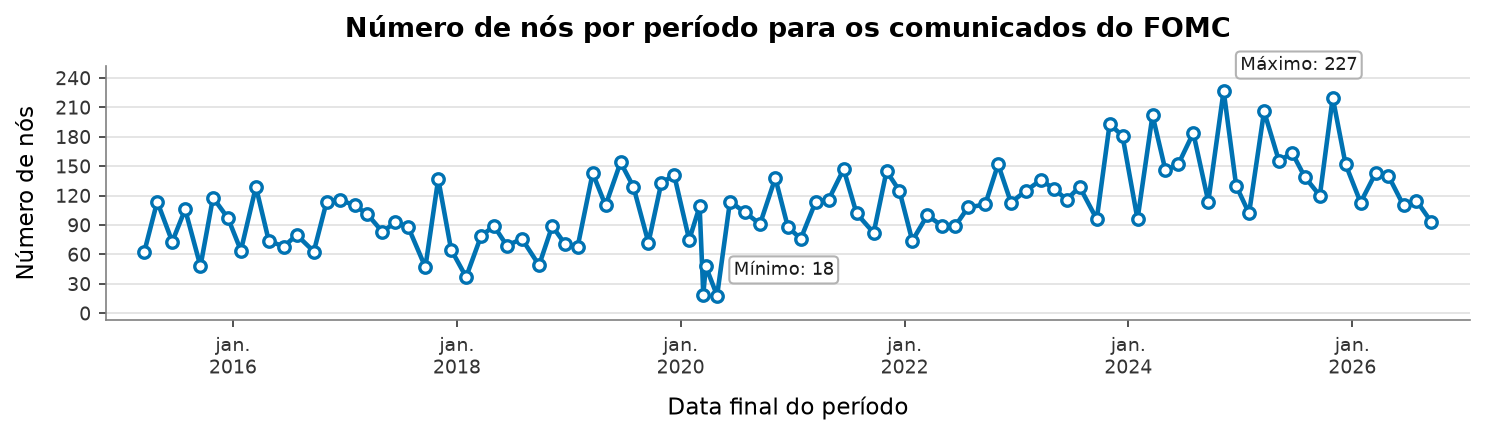

In [166]:
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, MaxNLocator

node_count_by_period = all_period_sentiment_scores.copy()
node_count_by_period['end_date'] = pd.to_datetime(node_count_by_period['end_date'])
node_count_by_period = node_count_by_period.sort_values('end_date')

month_abbreviations = [
    'jan.', 'fev.', 'mar.', 'abr.', 'maio', 'jun.',
    'jul.', 'ago.', 'set.', 'out.', 'nov.', 'dez.',
]

def format_date_pt_br(value, position):
    date = mdates.num2date(value)
    return f'{month_abbreviations[date.month - 1]}\n{date.year}'

fig, ax = plt.subplots(figsize=(10, 3), dpi=150)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(
    node_count_by_period['end_date'],
    node_count_by_period['node_count'],
    color='#0072B2',
    linewidth=2.2,
    marker='o',
    markersize=5.5,
    markerfacecolor='white',
    markeredgewidth=1.6,
    zorder=3,
)

for index, label in [
    (node_count_by_period['node_count'].idxmin(), 'Mínimo'),
    (node_count_by_period['node_count'].idxmax(), 'Máximo'),
]:
    period = node_count_by_period.loc[index]
    ax.annotate(
        f"{label}: {period['node_count']:.0f}",
        (period['end_date'], period['node_count']),
        xytext=(8, 10),
        textcoords='offset points',
        fontsize=8.5,
        color='#1A1A1A',
        bbox={'boxstyle': 'round,pad=0.25', 'facecolor': 'white', 'edgecolor': '#B3B3B3'},
    )

ax.set_title('Número de nós por período para os comunicados do FOMC', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Data final do período', fontsize=11, labelpad=8)
ax.set_ylabel('Número de nós', fontsize=11, labelpad=8)
ax.xaxis.set_major_formatter(FuncFormatter(format_date_pt_br))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis='y', color='#D9D9D9', linewidth=0.8, alpha=0.8, zorder=0)
ax.grid(axis='x', visible=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#808080')
ax.spines['bottom'].set_color('#808080')
ax.tick_params(axis='both', labelsize=9, colors='#333333')
ax.margins(x=0.03, y=0.12)

plt.tight_layout()
figure_path = path_proj / 'TCC_latex' / 'figuras' / 'node_count_by_fomc_period.png'
fig.savefig(figure_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f'Figure saved to {figure_path}')
plt.show()

Figure saved to c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\TCC_latex\figuras\similarity_cutoff_by_fomc_period.png


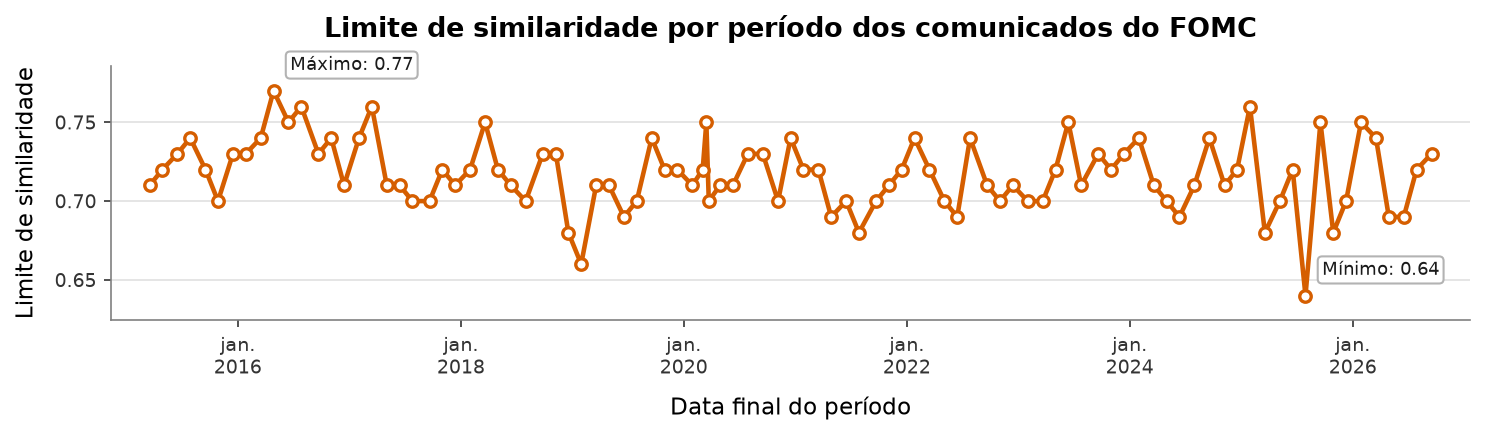

In [167]:
plot_data = all_period_sentiment_scores.copy()
plot_data['end_date'] = pd.to_datetime(plot_data['end_date'])
plot_data = plot_data.sort_values('end_date')

plot_definitions = [
    {
        'column': 'similarity_cutoff',
        'title': 'Limite de similaridade por período dos comunicados do FOMC',
        'ylabel': 'Limite de similaridade',
        'filename': 'similarity_cutoff_by_fomc_period.png',
        'color': '#D55E00',
        'integer_y': False,
    }
]

for plot_definition in plot_definitions:
    fig, ax = plt.subplots(figsize=(10, 3), dpi=150)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    ax.plot(
        plot_data['end_date'],
        plot_data[plot_definition['column']],
        color=plot_definition['color'],
        linewidth=2.2,
        marker='o',
        markersize=5.5,
        markerfacecolor='white',
        markeredgewidth=1.6,
        zorder=3,
    )

    if plot_definition['column'] == 'similarity_cutoff':
        minimum_index = plot_data[plot_definition['column']].idxmin()
        maximum_index = plot_data[plot_definition['column']].idxmax()
        for index, label in [
            (minimum_index, 'Mínimo'),
            (maximum_index, 'Máximo'),
        ]:
            period = plot_data.loc[index]
            ax.annotate(
                f"{label}: {period[plot_definition['column']]:.2f}",
                (period['end_date'], period[plot_definition['column']]),
                xytext=(8, 10),
                textcoords='offset points',
                fontsize=8.5,
                color='#1A1A1A',
                bbox={
                    'boxstyle': 'round,pad=0.25',
                    'facecolor': 'white',
                    'edgecolor': '#B3B3B3',
                },
            )

    ax.set_title(plot_definition['title'], fontsize=13, fontweight='bold', pad=14)
    ax.set_xlabel('Data final do período', fontsize=11, labelpad=8)
    ax.set_ylabel(plot_definition['ylabel'], fontsize=11, labelpad=8)
    ax.xaxis.set_major_formatter(FuncFormatter(format_date_pt_br))
    if plot_definition['integer_y']:
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis='y', color='#D9D9D9', linewidth=0.8, alpha=0.8, zorder=0)
    ax.grid(axis='x', visible=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#808080')
    ax.spines['bottom'].set_color('#808080')
    ax.tick_params(axis='both', labelsize=9, colors='#333333')
    ax.margins(x=0.03, y=0.12)

    plt.tight_layout()
    figure_path = path_proj / 'TCC_latex' / 'figuras' / plot_definition['filename']
    fig.savefig(figure_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Figure saved to {figure_path}")
    plt.show()


Figure saved to c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\TCC_latex\figuras\sentiment_indicators_centrality_by_fomc_period.png


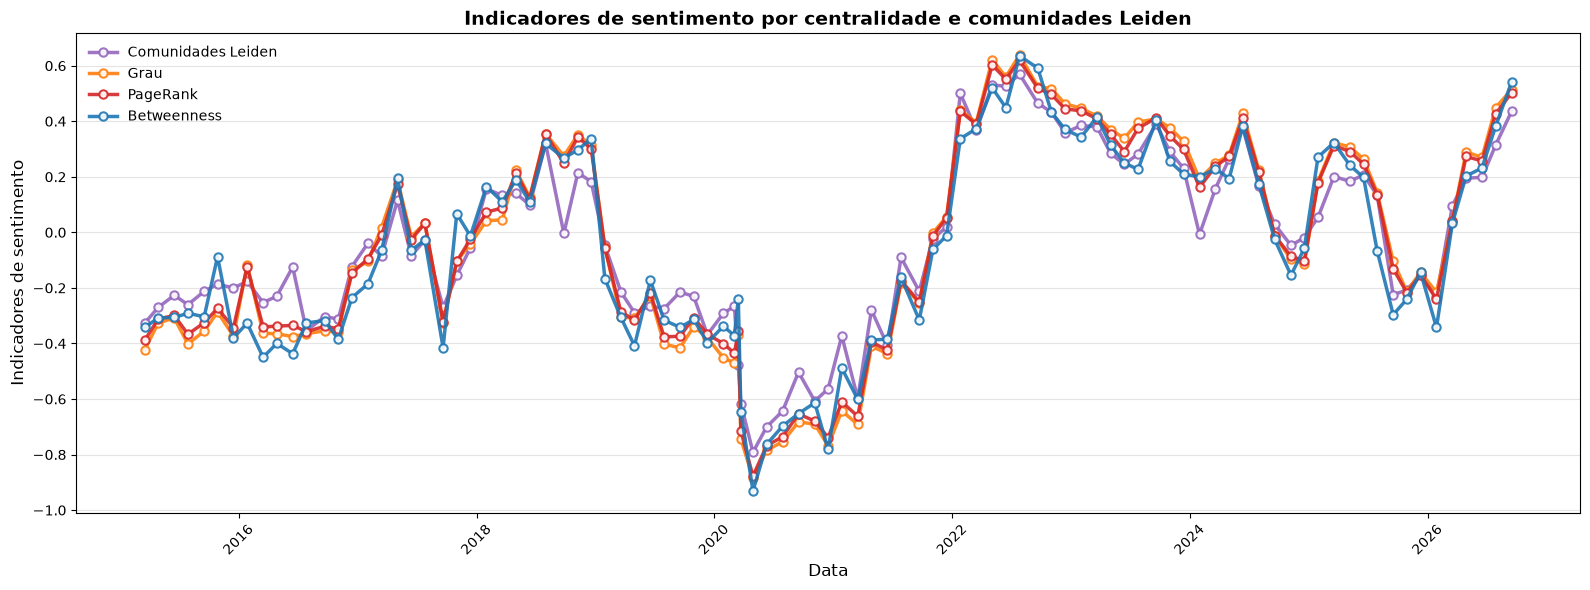

Figure saved to c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\TCC_latex\figuras\sentiment_indicators_centrality_community_by_fomc_period.png


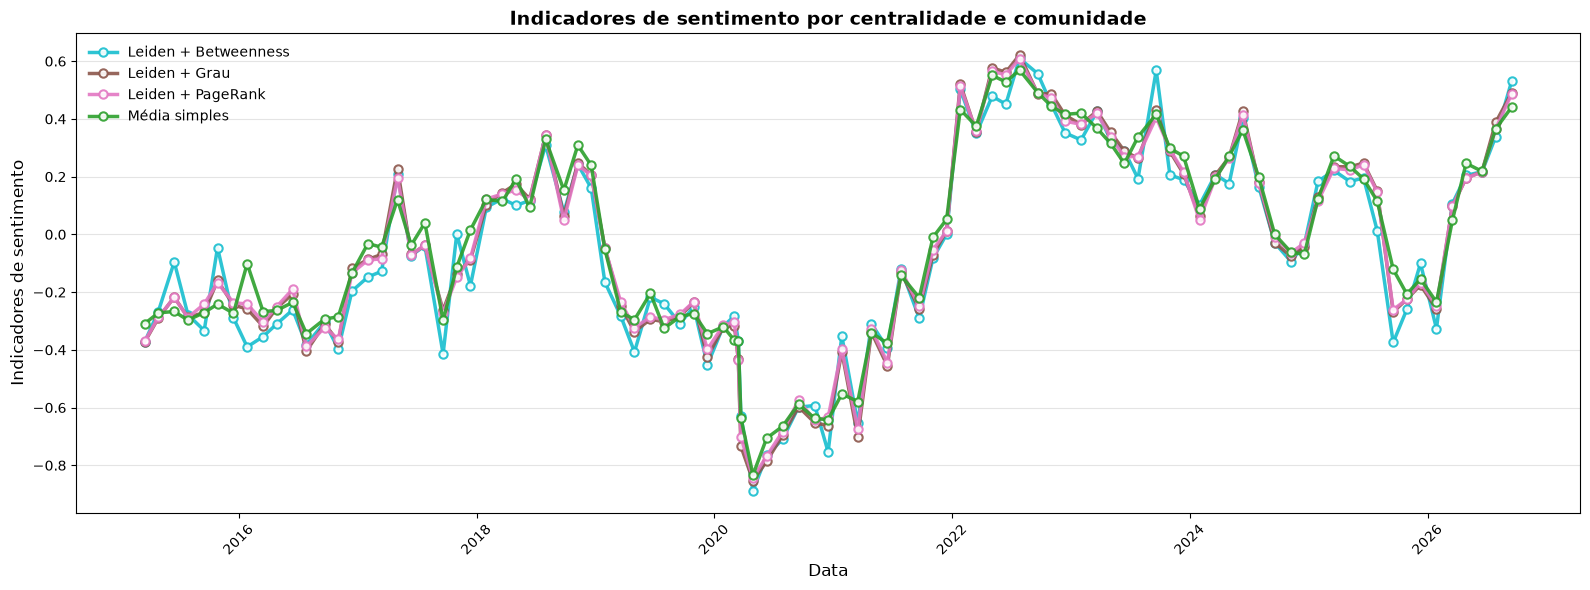

In [182]:
def analyze_sentiment_evolution(all_period_sentiment_scores, federal_funds_rate):
    """Analyze centrality and community sentiment indicators over time."""

    all_period_sentiment_scores = all_period_sentiment_scores.copy()
    all_period_sentiment_scores['end_date'] = pd.to_datetime(
        all_period_sentiment_scores['end_date']
    )

    sentiment_evolution = all_period_sentiment_scores.merge(
        federal_funds_rate,
        left_on='end_date',
        right_on='date',
        how='left'
    )

    sentiment_labels = {
        "betweenness_weighted_sentiment": "Betweenness",
        "degree_weighted_sentiment": "Grau",
        "pagerank_weighted_sentiment": "PageRank",
        "leiden_equal_weight_sentiment": "Comunidades Leiden",
        "leiden_betweenness_weighted_sentiment": "Leiden + Betweenness",
        "leiden_degree_weighted_sentiment": "Leiden + Grau",
        "leiden_pagerank_weighted_sentiment": "Leiden + PageRank",
        "simple_mean_sentiment": "Média simples",
    }

    centrality_columns = [
        "leiden_equal_weight_sentiment",
        "degree_weighted_sentiment",
        "pagerank_weighted_sentiment",
        "betweenness_weighted_sentiment",
    ]

    community_centrality_columns = [
        "leiden_betweenness_weighted_sentiment",
        "leiden_degree_weighted_sentiment",
        "leiden_pagerank_weighted_sentiment",
        "simple_mean_sentiment",
    ]

    def plot_sentiment_indicators(columns, title, output_name, colors):
        fig, ax = plt.subplots(figsize=(16, 6))

        for column, color in zip(columns, colors):
            ax.plot(
                sentiment_evolution['end_date'],
                sentiment_evolution[column],
                marker='o',
                markerfacecolor='white',
                markeredgewidth=1.5,
                linewidth=2.5,
                label=sentiment_labels[column],
                color=color,
                alpha=0.9,
            )

        ax.set_xlabel('Data', fontsize=12)
        ax.set_ylabel('Indicadores de sentimento', fontsize=12)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.grid(True, axis='y', color='#D9D9D9', alpha=0.7)
        ax.tick_params(axis='x', rotation=45)
        ax.legend(loc='upper left', fontsize=10, frameon=False)

        plt.tight_layout()
        output_path = path_proj / 'TCC_latex' / 'figuras' / output_name
        fig.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f'Figure saved to {output_path}')
        plt.show()

    plot_sentiment_indicators(
        centrality_columns,
        'Indicadores de sentimento por centralidade e comunidades Leiden',
        'sentiment_indicators_centrality_by_fomc_period.png',
        ['tab:purple', 'tab:orange', 'tab:red', 'tab:blue'],
    )

    plot_sentiment_indicators(
        community_centrality_columns,
        'Indicadores de sentimento por centralidade e comunidade',
        'sentiment_indicators_centrality_community_by_fomc_period.png',
        ['tab:cyan', 'tab:brown', 'tab:pink', 'tab:green'],
    )

    return sentiment_evolution

sentiment_evolution = analyze_sentiment_evolution(
    all_period_sentiment_scores,
    df_fred_statement_dates,
 )

In [169]:
sentiment_columns = [
    "betweenness_weighted_sentiment",
    "degree_weighted_sentiment",
    "pagerank_weighted_sentiment",
    "leiden_equal_weight_sentiment",
    "leiden_betweenness_weighted_sentiment",
    "leiden_degree_weighted_sentiment",
    "leiden_pagerank_weighted_sentiment",
    "simple_mean_sentiment",
]

sentiment_labels = {
    "betweenness_weighted_sentiment": "Betweenness",
    "degree_weighted_sentiment": "Grau",
    "pagerank_weighted_sentiment": "PageRank",
    "leiden_equal_weight_sentiment": "Comunidades Leiden",
    "leiden_betweenness_weighted_sentiment": "Leiden + Betweenness",
    "leiden_degree_weighted_sentiment": "Leiden + Grau",
    "leiden_pagerank_weighted_sentiment": "Leiden + PageRank",
    "simple_mean_sentiment": "Média simples",
}

correlation_data = sentiment_evolution[
    sentiment_columns + ["upper_rate_change"]
].dropna()

pearson_correlations = (
    correlation_data.corr(method="pearson")["upper_rate_change"]
    .drop("upper_rate_change")
    .rename("correlacao_pearson")
    .rename(index=sentiment_labels)
    .sort_values(ascending=False)
    .to_frame()
 )

pearson_correlations.index.name = "indicador"
pearson_correlations.round(3)

,correlacao_pearson
indicador,
Comunidades Leiden,0.531
Leiden + Grau,0.530
Leiden + PageRank,0.527
Média simples,0.517
Leiden + Betweenness,0.503
PageRank,0.503
Grau,0.500
Betweenness,0.487


In [170]:
# all_period_sentiment_scores = pd.read_csv(path_data / "period_sentiment_scores.csv")
# sentiment_evolution = analyze_sentiment_evolution(all_period_sentiment_scores, df_fred_statement_dates)
# sentiment_evolution[["end_date", "upper_rate_change"]].head()

# Selecionando limite de similaridade

In [171]:
saved_period_scores = pd.read_csv(path_data / 'period_sentiment_scores.csv')
constant_similarity_cutoff = saved_period_scores['similarity_cutoff'].median()
print(f'Corte de similaridade constante selecionado pela mediana: {constant_similarity_cutoff:.2f}')

Corte de similaridade constante selecionado pela mediana: 0.72


In [172]:
FIXED_SIMILARITY_CUTOFF = constant_similarity_cutoff


def analyze_all_statement_periods_fixed_cutoff(
    dates_fomc_statement,
    similarity_cutoff=FIXED_SIMILARITY_CUTOFF,
):
    period_scores = []

    for start_date, end_date in zip(
        dates_fomc_statement[:-1],
        dates_fomc_statement[1:],
    ):
        print(
            f"Analyzing {start_date} to {end_date} "
            f"with fixed similarity cutoff {similarity_cutoff:.2f}"
        )
        create_similar_connections(start_date, end_date, similarity_cutoff)
        run_wcc(start_date, end_date)
        period_score = calculate_period_sentiment_score(start_date, end_date)
        period_score["similarity_cutoff"] = similarity_cutoff
        period_scores.append(period_score)

    return pd.concat(period_scores, ignore_index=True)


fixed_period_sentiment_scores = analyze_all_statement_periods_fixed_cutoff(
    dates_fomc_statement
)

fixed_period_sentiment_scores.to_csv(
    path_data / "period_sentiment_scores_fixed.csv",
    index=False,
)

fixed_period_sentiment_scores.head()

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Analyzing 2015-01-28 to 2015-03-18 with fixed similarity cutoff 0.72
1872 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 63


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Criadas 494 relationships SIMILAR_TO
Projection 'signal-wcc' removed
Projection 'signal-wcc': 63 nodes, 1976 relationships
2 communities
Analyzing 2015-03-18 to 2015-04-29 with fixed similarity cutoff 0.72
988 SIMILAR_TO relationships removed


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


...

Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Analyzing 2026-07-29 to 2026-09-16 with fixed similarity cutoff 0.72
2934 SIMILAR_TO relationships removed
Projection 'signal-cypher' removed
Created graph 'signal-cypher' with 93


Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `schema` returned by the procedure `gds.graph.drop` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL gds.graph.drop($projection_name)'


Criadas 1171 relationships SIMILAR_TO
Projection 'signal-wcc' removed
Projection 'signal-wcc': 93 nodes, 4684 relationships
1 communities


,start_date,end_date,node_count,relationship_count,number_of_leiden_communities,largest_leiden_community_size,leiden_equal_weight_sentiment,leiden_betweenness_weighted_sentiment,leiden_degree_weighted_sentiment,leiden_pagerank_weighted_sentiment,simple_mean_sentiment,betweenness_weighted_sentiment,degree_weighted_sentiment,pagerank_weighted_sentiment,similarity_cutoff
0,2015-01-28,2015-03-18,63,1976,5,23,-0.327014,-0.613690,-0.393442,-0.386918,-0.309524,-0.556655,-0.439581,-0.401183,0.72
1,2015-03-18,2015-04-29,114,6712,5,32,-0.269858,-0.267289,-0.289873,-0.287589,-0.271930,-0.308037,-0.325871,-0.311888,0.72
2,2015-04-29,2015-06-17,73,2792,4,23,-0.254220,-0.155078,-0.293298,-0.272651,-0.267123,-0.105348,-0.285179,-0.279008,0.72
3,2015-06-17,2015-07-29,106,6920,4,46,-0.257949,-0.265675,-0.276352,-0.275937,-0.297170,-0.320242,-0.373133,-0.349567,0.72
4,2015-07-29,2015-09-17,48,1556,5,12,-0.212381,-0.333108,-0.270463,-0.241466,-0.270833,-0.303870,-0.355758,-0.325187,0.72


Figure saved to c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\TCC_latex\figuras\relationship_count_by_fomc_period_fixed_cutoff.png


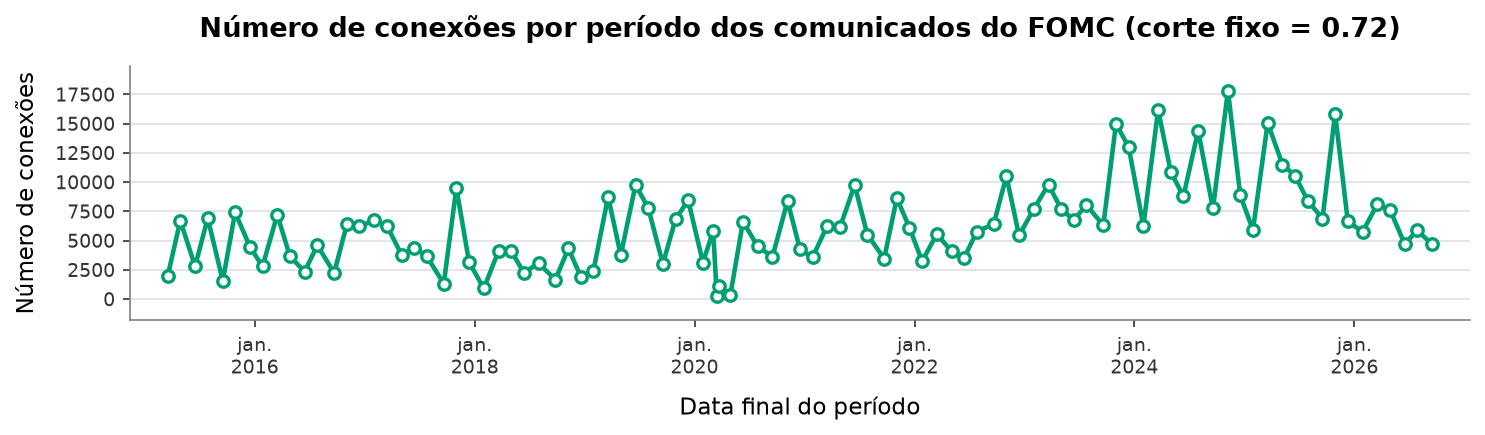

In [173]:
fixed_plot_data = fixed_period_sentiment_scores.copy()
fixed_plot_data["end_date"] = pd.to_datetime(fixed_plot_data["end_date"])
fixed_plot_data = fixed_plot_data.sort_values("end_date")

fig, ax = plt.subplots(figsize=(10, 3), dpi=150)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.plot(
    fixed_plot_data["end_date"],
    fixed_plot_data["relationship_count"],
    color="#009E73",
    linewidth=2.2,
    marker="o",
    markersize=5.5,
    markerfacecolor="white",
    markeredgewidth=1.6,
    zorder=3,
)

ax.set_title(
    f"Número de conexões por período dos comunicados do FOMC "
    f"(corte fixo = {FIXED_SIMILARITY_CUTOFF:.2f})",
    fontsize=13,
    fontweight="bold",
    pad=14,
)
ax.set_xlabel("Data final do período", fontsize=11, labelpad=8)
ax.set_ylabel("Número de conexões", fontsize=11, labelpad=8)
ax.xaxis.set_major_formatter(FuncFormatter(format_date_pt_br))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis="y", color="#D9D9D9", linewidth=0.8, alpha=0.8, zorder=0)
ax.grid(axis="x", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#808080")
ax.spines["bottom"].set_color("#808080")
ax.tick_params(axis="both", labelsize=9, colors="#333333")
ax.margins(x=0.03, y=0.12)

plt.tight_layout()
fixed_figure_path = (
    path_proj
    / "TCC_latex"
    / "figuras"
    / "relationship_count_by_fomc_period_fixed_cutoff.png"
)
fig.savefig(fixed_figure_path, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Figure saved to {fixed_figure_path}")
plt.show()

In [174]:
fixed_scores_for_correlation = pd.read_csv(
    path_data / "period_sentiment_scores_fixed.csv",
    parse_dates=["start_date", "end_date"],
)

fixed_sentiment_evolution = fixed_scores_for_correlation.merge(
    df_fred_statement_dates,
    left_on="end_date",
    right_on="date",
    how="left",
)

fixed_sentiment_columns = [
    "betweenness_weighted_sentiment",
    "degree_weighted_sentiment",
    "pagerank_weighted_sentiment",
    "leiden_equal_weight_sentiment",
    "leiden_betweenness_weighted_sentiment",
    "leiden_degree_weighted_sentiment",
    "leiden_pagerank_weighted_sentiment",
    "simple_mean_sentiment",
]

fixed_sentiment_labels = {
    "betweenness_weighted_sentiment": "Betweenness",
    "degree_weighted_sentiment": "Grau",
    "pagerank_weighted_sentiment": "PageRank",
    "leiden_equal_weight_sentiment": "Comunidades Leiden",
    "leiden_betweenness_weighted_sentiment": "Leiden + Betweenness",
    "leiden_degree_weighted_sentiment": "Leiden + Grau",
    "leiden_pagerank_weighted_sentiment": "Leiden + PageRank",
    "simple_mean_sentiment": "Média simples",
}

fixed_correlation_data = fixed_sentiment_evolution[
    fixed_sentiment_columns + ["upper_rate_change"]
].dropna()

fixed_pearson_correlations = (
    fixed_correlation_data.corr(method="pearson")["upper_rate_change"]
    .drop("upper_rate_change")
    .rename("correlacao_pearson")
    .rename(index=fixed_sentiment_labels)
    .sort_values(ascending=False)
    .to_frame()
 )

fixed_pearson_correlations.index.name = "indicador"
fixed_pearson_correlations.round(3)

,correlacao_pearson
indicador,
Betweenness,0.531
Média simples,0.517
Leiden + Betweenness,0.513
PageRank,0.506
Grau,0.501
Leiden + Grau,0.499
Comunidades Leiden,0.499
Leiden + PageRank,0.491


Figure saved to c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\TCC_latex\figuras\sentiment_indicators_centrality_by_fomc_period.png


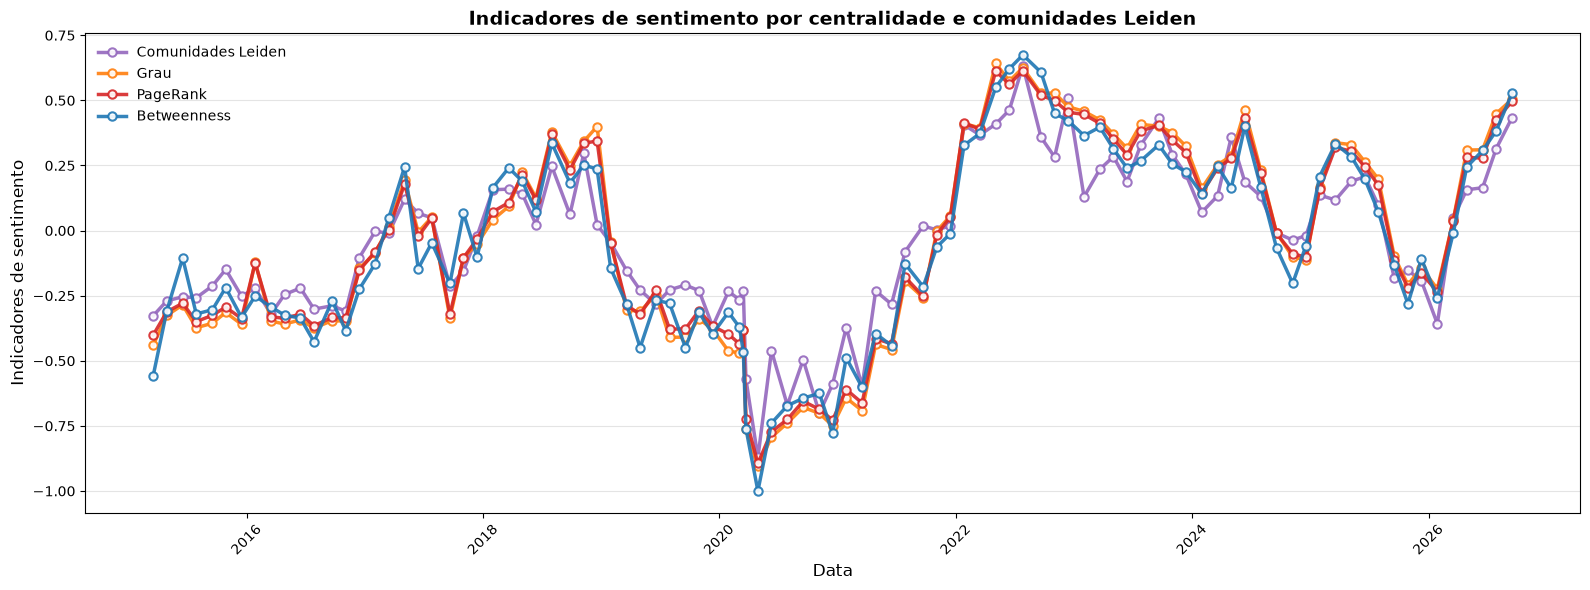

Figure saved to c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\TCC_latex\figuras\sentiment_indicators_centrality_community_by_fomc_period.png


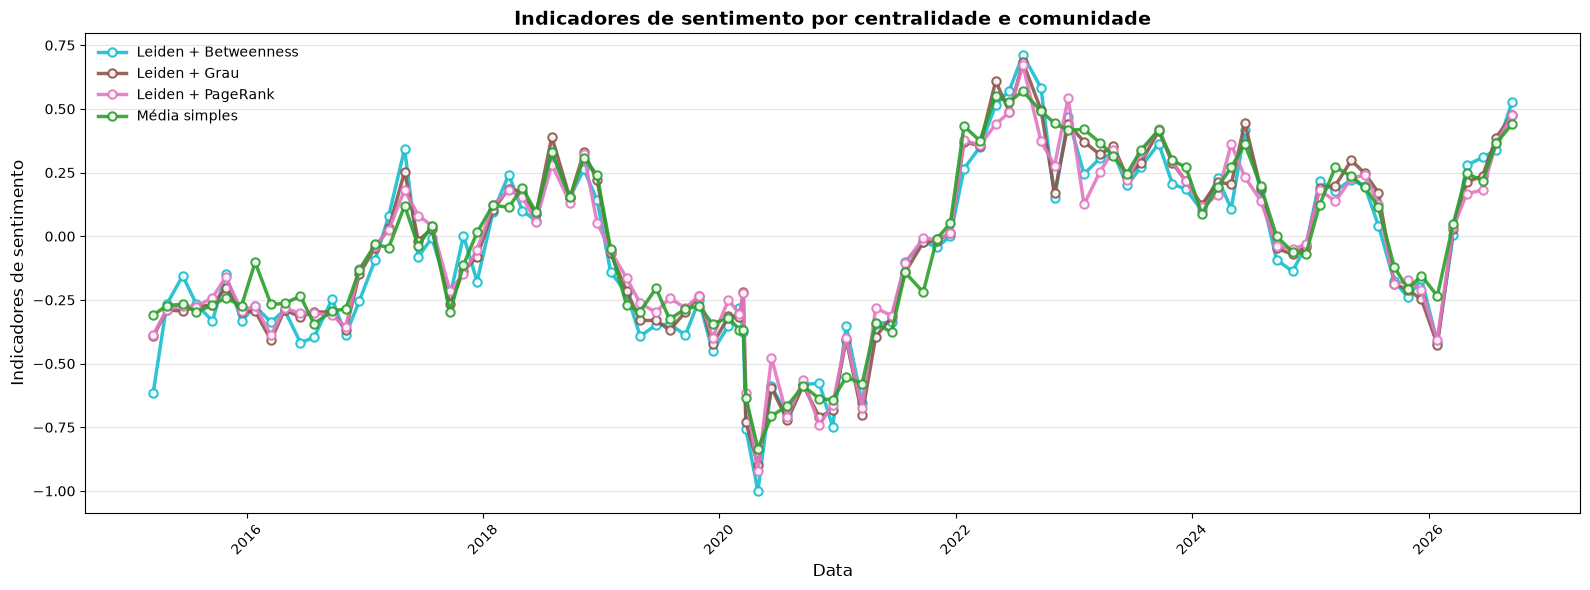

Figure saved to c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\TCC_latex\figuras\sentiment_indicators_centrality_by_fomc_period_fixed.png
Figure saved to c:\Users\ander\OneDrive\Cursos\MBA ciencia de dados EsalqUSP\tcc\TCC_latex\figuras\sentiment_indicators_centrality_community_by_fomc_period_fixed.png


In [184]:
from shutil import copyfile

fixed_scores_for_graphs = pd.read_csv(
    path_data / "period_sentiment_scores_fixed.csv",
    parse_dates=["start_date", "end_date"],
)

analyze_sentiment_evolution(
    fixed_scores_for_graphs,
    df_fred_statement_dates,
)

figures_path = path_proj / "TCC_latex" / "figuras"
fixed_graph_names = {
    "sentiment_indicators_centrality_by_fomc_period.png": (
        "sentiment_indicators_centrality_by_fomc_period_fixed.png"
    ),
    "sentiment_indicators_centrality_community_by_fomc_period.png": (
        "sentiment_indicators_centrality_community_by_fomc_period_fixed.png"
    ),
}

for source_name, fixed_name in fixed_graph_names.items():
    source_path = figures_path / source_name
    fixed_path = figures_path / fixed_name
    copyfile(source_path, fixed_path)
    print(f"Figure saved to {fixed_path}")